# Problem 2.1

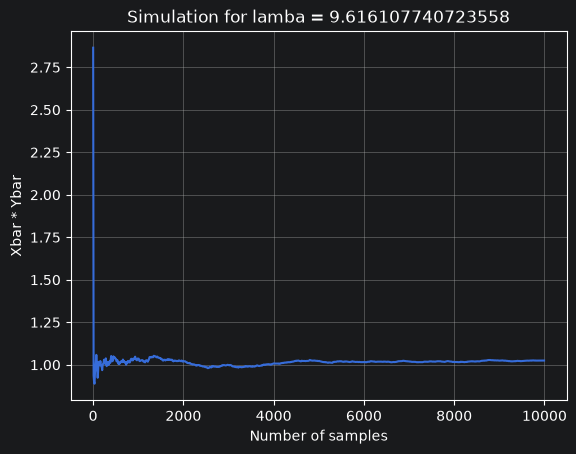

In [30]:
import numpy as np
import matplotlib.pyplot as plt
# Some random lambda parameter
l = np.random.uniform(low=1, high=10)

# Sample
N = 10000
X = np.random.exponential(scale=1/l, size = N)
Y = np.random.exponential(scale= l , size = N)
R = range(1, N, 10)

# Compute asymptotic mean product
mean_product = []
for n in R:
    Xbar = np.mean(X[:n])
    Ybar = np.mean(Y[:n])
    mean_product.append(Xbar * Ybar)

plt.plot(R, mean_product)
plt.xlabel('Number of samples')
plt.ylabel('Xbar * Ybar')
plt.title(f'Simulation for lamba = {l}')
plt.grid()









# Problem 2.2

We have found the MLE for the linear normal model $Y_j \sim N(\beta x_j, \sigma^2)$, $j = 1, \ldots, n$ to be $\hat{\beta} = \frac{\sum_{j=1}^{n} y_j x_j}{\sum_{j=1}^{n} x_j^2}$ and $\hat{\sigma}^2 = \frac{1}{n} \sum_{j=1}^{n} (y_j - \hat{\beta} x_j)^2$.

These estmates come from the log-likelihood function:
$$
\ell(\beta, \sigma^2) = -\frac{n}{2} \log(2 \pi) - \frac{n}{2} \log(\sigma^2) - \frac{1}{2\sigma^2} \sum_{j=1}^{n} (y_j - \beta x_j)^2
$$
With first derivatives:
$$
\frac{\partial \ell}{\partial \beta} = \frac{1}{\sigma^2} \sum_{j=1}^{n} (y_j - \beta x_j) x_j
$$
$$
\frac{\partial \ell}{\partial \sigma^2} = -\frac{
n}{2\sigma^2} + \frac{1}{2\sigma^4} \sum_{j=1}^{n} (y_j - \beta x_j)^2
$$

Looking at the first derivative with respect to $\beta$, we find the mixed derivative:
$$
\frac{\partial^2 \ell}{\partial \beta \partial \sigma^2} = -\frac{1}{\sigma^4} \sum_{j=1}^{n} (y_j - \beta x_j) x_j
$$
And the second derivative with respect to $\beta$:
$$
\dfrac{\partial^2 \ell}{\partial \beta^2} = -\frac{1}{\sigma^2} \sum_{j=1}^{n} x_j^2
$$
and the second derivative with respect to $\sigma^2$:
$$
\dfrac{\partial^2 \ell}{\partial (\sigma^2)^2} =
\frac{n}{2\sigma^4} - \frac{1}{\sigma^6} \sum_{j=1}^{n} (y_j - \beta x_j)^2
$$

If we evaluate the second mixed derivative at the MLE, we find that it is zero:
$$
\frac{\partial^2 \ell}{\partial \beta \partial \sigma^2} \Bigg|_{\hat{\beta}, \hat{\sigma}^2} = -\frac{1}{\hat{\sigma^2}^2} \sum_{j=1}^{n} (y_j - \hat{\beta} x_j) x_j = -\frac{1}{\hat{\sigma^2}^2} \sum_{j=1}^{n} (y_j - \frac{\sum_{j=1}^{n} y_j x_j}{\sum_{j=1}^{n} x_j^2} x_j) x_j = 0
$$
Thus we get the oberved information matrix:
$$
J(\hat{\beta}, \hat{\sigma}^2) = -\begin{bmatrix}
\dfrac{\partial^2 \ell}{\partial \beta^2} \Big|_{\hat{\beta}, \hat{\sigma}^2} & \dfrac{\partial^2 \ell}{\partial \beta \partial \sigma^2} \Big|_{\hat{\beta}, \hat{\sigma}^2} \\
\dfrac{\partial^2 \ell}{\partial \sigma^2 \partial \beta} \Big|_{\hat{\beta}, \hat{\sigma}^2} & \dfrac{\partial^2 \ell}{\partial (\sigma^2)^2} \Big|_{\hat{\beta}, \hat{\sigma}^2}
\end{bmatrix}
$$
If we use the fact that mixed derivative is zero, we can simplify the observed information matrix to:
$$
J(\hat{\beta}, \hat{\sigma}^2) = -\begin{bmatrix}
\dfrac{\partial^2 \ell}{\partial \beta^2} \Big|_{\hat{\beta} & 0 \\
0 & \dfrac{\partial^2 \ell}{\partial (\sigma^2)^2} \Big|_{\hat{\beta}, \hat{\sigma}^2}
\end{bmatrix}
$$
Inserting the second derivatives, we get:
$$
J(\hat{\beta}, \hat{\sigma}^2) = -\begin{bmatrix}
   -\frac{1}{\hat\sigma^2} \sum_{j=1}^{n} x_j^2 & 0 \\
0 & \dfrac{n}{2\hat{\sigma}^4} - \dfrac{1}{\hat{\sigma}^6} \sum_{j=1}^{n} (y_j - \hat{\beta} x_j)^2
\end{bmatrix}
$$

In [8]:
# Given data:
import numpy as np
x = np.array([1, 2, 3, 4, 5])
y = np.array([2.81, 5.48, 7.11, 8.69, 11.28])

beta_hat = lambda x, y: np.sum(y * x) / np.sum(np.power(x, 2))
sigma_hat_sqr = lambda x, y: np.sum((y - beta_hat(x,y) * x)**2) / len(x)
J11 = lambda x, sigma_sqr: -(-1/sigma_sqr * np.sum(x**2))
J22 = lambda x, y: - (len(x) * 0.5 * (1/sigma_hat_sqr(x,y) ** 2) - (1 / sigma_hat_sqr(x,y) ** 3) * np.sum(y - beta_hat(x,y)*x)**2)
J = np.zeros((2, 2))
J[0, 0] = J11(x, sigma_hat_sqr(x,y))
J[1, 1] = J22(x, y)
print("Observed Information Matrix J:")
print(J)


Observed Information Matrix J:
[[198.40515053   0.        ]
 [  0.           8.5459172 ]]


In [ ]:
# Plot of data
import matplotlib.pyplot as plt



We then get the cofidence interval for the $\beta$ parameter

In [9]:
z_alpha = 1.96
beta_hat_value = beta_hat(x, y)
standard_error = np.sqrt(1 / J[0, 0])
confidence_interval = (beta_hat_value - z_alpha * standard_error, beta_hat_value + z_alpha * standard_error)
print(f"95% Confidence Interval for beta: {confidence_interval}")

95% Confidence Interval for beta: (np.float64(2.1564875204099834), np.float64(2.434785206862743))


And for the $\sigma^2$ parameter

In [10]:
sigma_hat_value = sigma_hat_sqr(x, y)
standard_error_sigma = np.sqrt(1 / J[1, 1])
confidence_interval_sigma = (sigma_hat_value - z_alpha * standard_error_sigma, sigma_hat_value + z_alpha * standard_error_sigma)
print(f"95% Confidence Interval for sigma^2: {confidence_interval_sigma}")

95% Confidence Interval for sigma^2: (np.float64(-0.393255410787508), np.float64(0.9476765016965998))


We plot the data and the fitted line

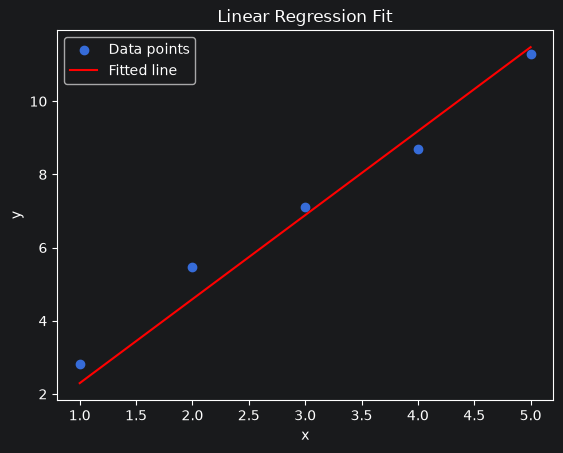

In [11]:
plt.scatter(x, y, label='Data points')
plt.plot(x, beta_hat_value * x, color='red', label='Fitted line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()